In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
ratings = pd.read_csv("./ml-latest-small/ratings.csv")
movies = pd.read_csv("./ml-latest-small/movies.csv")

### EDA

In [4]:
ratings_count = len(ratings)
users_count = ratings['userId'].nunique()
movies_count = ratings['movieId'].nunique()

max_possibile = users_count * movies_count

sparsity_of_matrix = 1 - (ratings_count / max_possibile)

print(f"Sparsity of Matrix: {sparsity_of_matrix}")


Sparsity of Matrix: 0.9830003169443864


Matrix is highly sparse.

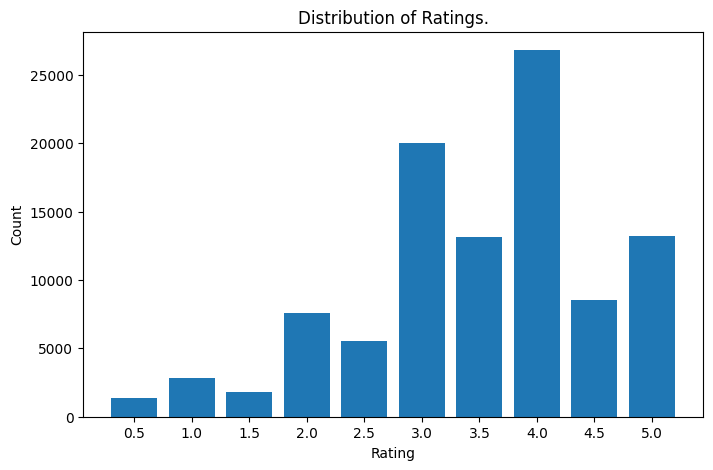

Ratings distribution:  rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt

ratings_distribution = ratings['rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(ratings_distribution.index.astype(str), ratings_distribution.values)

plt.xlabel('Rating')
plt.ylabel('Count')
plt.title("Distribution of Ratings.")
plt.show()
print("Ratings distribution: ", ratings['rating'].value_counts().sort_index())

EDA shows that, the matrix is 98% sparse. Also the graph shows that, the ratings are skewed and are maxed at 4.

# Approach 1: Memory based

In [6]:
ratings = ratings[['userId', 'movieId', 'rating']]

train_df, test_df = train_test_split(ratings, test_size=0.2)

In [7]:
matrix_item_user = train_df.pivot(index='movieId', columns="userId", values="rating")

global_mean = train_df['rating'].mean()

filled_matrix = matrix_item_user.fillna(0)
filled_matrix

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,4.0,0.0,4.0,2.5,0.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193573,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
193579,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
193583,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
itm_similarity = cosine_similarity(filled_matrix)

itm_similarity = pd.DataFrame(itm_similarity, index=matrix_item_user.index, columns=matrix_item_user.index)


In [9]:
def pred_mem_based(user_id, item_id):
    if item_id not in itm_similarity.index or user_id not in matrix_item_user:
        return global_mean

    user_ratings = matrix_item_user[user_id]
    rated_movies = user_ratings.dropna()
    if rated_movies.empty:
        return global_mean

    similarities = itm_similarity.loc[item_id, rated_movies.index]

    sum_w = np.dot(similarities, rated_movies)
    sum = np.abs(similarities).sum()

    if sum == 0:
        return rated_movies.mean()

    return sum_w / sum

In [10]:
test_preds = [
    pred_mem_based(row.userId, row.movieId) 
    for row in test_df.itertuples()
]

In [11]:
rmse = np.sqrt(mean_squared_error(test_df['rating'], test_preds))

In [12]:
rmse

np.float64(0.9213161739997061)

# Approach 2

In [166]:
unique_users = train_df['userId'].unique()
unique_movies = train_df['movieId'].unique()

user_to_idx = {uid:i for i, uid in enumerate(unique_users)}
movie_to_idx = {uid: i for i, uid in enumerate(unique_movies)}

num_users = len(unique_users)
num_movies = len(unique_movies)

In [167]:
train_df['u_idx'] = train_df['userId'].map(user_to_idx)
train_df['m_idx'] = train_df['movieId'].map(movie_to_idx)

In [168]:
import time
from sklearn.metrics import mean_squared_error

In [218]:
n_factors = 15
lr = 0.002
reg = 0.01
n_epochs = 30

In [219]:
global_mean = train_df['rating'].mean()

b_u = np.zeros(num_users)
b_i = np.zeros(num_movies)

P = np.random.normal(scale=1./n_factors, size=(num_users, n_factors))
Q = np.random.normal(scale=1./n_factors, size=(num_movies, n_factors))

train_data = train_df[['u_idx', 'm_idx', 'rating']].values

In [220]:
# Training
for epoch in range(n_epochs):

    np.random.shuffle(train_data)

    for row in train_data:
        u = int(row[0])
        m = int(row[1])
        r_ui = int(row[2])

        prediction = global_mean + b_u[u] + b_i[m] + np.dot(P[u], Q[m])

        error = r_ui - prediction

        b_u[u] += lr * (error - reg * b_u[u])
        b_i[m] += lr * (error - reg * b_i[m])

        temp_Pu = P[u].copy()

        P[u] += lr * (error * Q[m] - reg * b_u[u])
        Q[m] += lr * (error * temp_Pu - reg * b_i[m])
    print(f"Epoch {epoch+1}/{n_epochs}")

Epoch 1/30
Epoch 2/30
Epoch 3/30
Epoch 4/30
Epoch 5/30
Epoch 6/30
Epoch 7/30
Epoch 8/30
Epoch 9/30
Epoch 10/30
Epoch 11/30
Epoch 12/30
Epoch 13/30
Epoch 14/30
Epoch 15/30
Epoch 16/30
Epoch 17/30
Epoch 18/30
Epoch 19/30
Epoch 20/30
Epoch 21/30
Epoch 22/30
Epoch 23/30
Epoch 24/30
Epoch 25/30
Epoch 26/30
Epoch 27/30
Epoch 28/30
Epoch 29/30
Epoch 30/30


In [221]:
def predict_mat_fac(user_id, movie_id):
    if user_id not in user_to_idx or movie_id not in movie_to_idx:
        return global_mean

    u = user_to_idx[user_id]
    m = movie_to_idx[movie_id]

    pred = global_mean + b_u[u] + b_i[m] + np.dot(P[u], Q[m])

    if np.isnan(pred): 
        return global_mean

    if pred < 0.5: return 0.5
    if pred > 5.0: return 5.0 

    return pred


In [222]:

test_preds_2 = [
    predict_mat_fac(row.userId, row.movieId) for row in test_df.itertuples()
]

In [223]:
rmse_mf = mean_squared_error(test_df['rating'], test_preds_2)
rmse_mf

0.7978898917789212

In [224]:
train_preds_2 = [
    predict_mat_fac(row.userId, row.movieId) for row in train_df.itertuples()
]

rmse_mf_tr = mean_squared_error(train_df['rating'], train_preds_2)
rmse_mf_tr

0.6883220208888342